In [1]:
import jpybinding as jpb
import matplotlib.pyplot as plt
import numpy as np
import scipy as sci

In [2]:
np.array([[-2],[-3]]).shape

(2, 1)

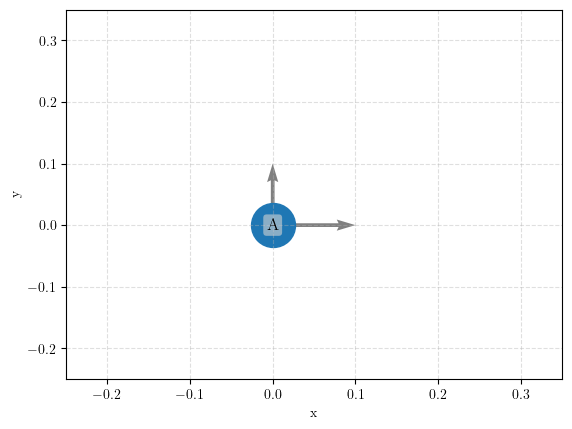

In [3]:
lat=jpb.Lattice(a1=[0.1,0],a2=[0,0.1])

# lat.add_sublattices(
#     ("A", [0,0],np.eye(2)),
#     ("B", [0.5,0.5])
# )

# lat.add_hoppings(
#     ([1,0], "A", "B", np.array([[-2],[-3]])),
# )

lat.add_sublattices(
    ("A", [0,0])
)

lat.add_hoppings(
    ([1,0], "A", "A", -1),
    ([0,1], "A", "A", -1),
)



lat.plot()

In [4]:
lat.sub_index_orb
lat.norbs

1

In [5]:
a1=np.array(list(lat.a1)+[0])


print(a1)

[0.1 0.  0. ]


In [6]:
model=jpb.Model(lat,'k',16,16)


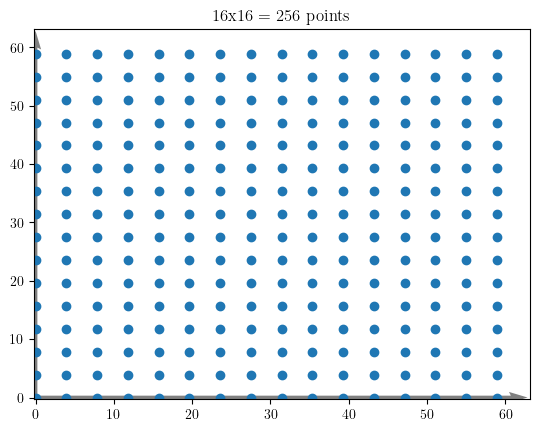

In [7]:
model.plot()

In [8]:
Gamma=[0,0]
X=[10*np.pi,10*np.pi]
k_points=[Gamma,X,Gamma]




In [9]:
solver=jpb.Solver(model)

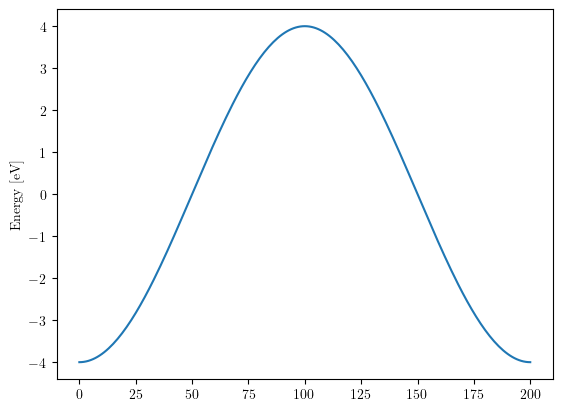

In [10]:
solver.calc_bands([Gamma,X,Gamma],True)

# Graphene

In [11]:
np.asarray(1)

array(1)

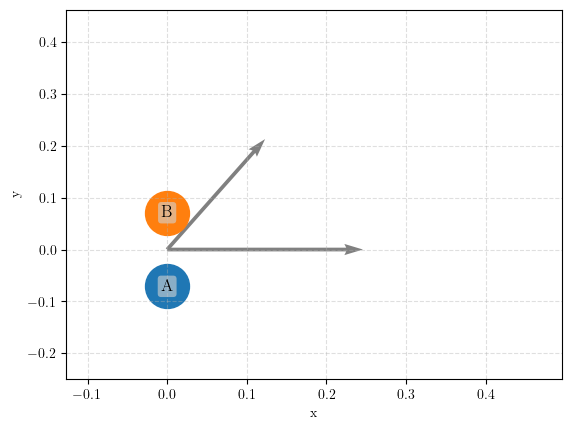

In [12]:
m=0
a = 0.24595   # [nm] unit cell length
a_cc = 0.142  # [nm] carbon-carbon distance
t=-2.7
lat=jpb.Lattice(a1=[a, 0],a2=[a/2, a/2 * np.sqrt(3)])

lat.add_sublattices(('A', [0, -a_cc/2],m),
                    ('B', [0,  a_cc/2],-m)
)

lat.add_hoppings(
    # inside the main cell
    ([0,  0], 'A', 'B', t),
    # between neighboring cells
    ([1, -1], 'A', 'B', t),
    ([0, -1], 'A', 'B', t)
)



lat.plot()



In [13]:
print(lat.hoppings)
print(0*lat.a1)

[{'relative_index': [0, 0], 'from': 'A', 'to': 'B', 'energy': array(-2.7+0.j)}, {'relative_index': [1, -1], 'from': 'A', 'to': 'B', 'energy': array(-2.7+0.j)}, {'relative_index': [0, -1], 'from': 'A', 'to': 'B', 'energy': array(-2.7+0.j)}]
[0. 0.]


In [14]:
np.asarray(np.array([1,2]))

array([1, 2])

In [15]:
model=jpb.Model(lat,'k',16,16)
solver=jpb.Solver(model)


In [16]:
list(range(0,3*100,100))

[0, 100, 200]

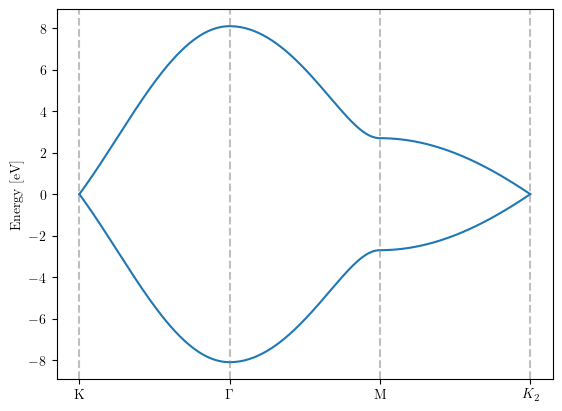

In [17]:
Gamma = [0, 0]
K1 = [-4*np.pi / (3*np.sqrt(3)*a_cc), 0]
M = [0, 2*np.pi / (3*a_cc)]
K2 = [2*np.pi / (3*np.sqrt(3)*a_cc), 2*np.pi / (3*a_cc)]

k_points=[K1,Gamma,M,K2]

ene_mat=solver.calc_bands(k_points,True,[r'K',r'$\Gamma$',r'M',r'$K_2$'])



# Haldane

In [18]:
def pb_lattice_Haldane(t=-2.7,m=0,t2=2/(3*np.sqrt(3))):

    a = 0.24595   # [nm] unit cell length
    a_cc = 0.142  # [nm] carbon-carbon distance

    lat = jpb.Lattice(
        a1=[a, 0],
        a2=[a/2, a/2 * np.sqrt(3)]
    )

    lat.add_sublattices(
        # name and position
        ('A', [0, -a_cc/2],-m),
        ('B', [0,  a_cc/2],m)
    )

    lat.add_hoppings(
        # inside the main cell
        ([0,  0], 'A', 'B', t),
        # between neighboring cells
        ([1, -1], 'A', 'B', t),
        ([0, -1], 'A', 'B', t),

        ([1, 0], 'A', 'A', t2 * 1j),
        ([0, -1], 'A', 'A', t2 * 1j),
        ([-1, 1], 'A', 'A', t2 * 1j),

        ([1, 0], 'B', 'B', t2 * -1j),
        ([0, -1], 'B', 'B', t2 * -1j),
        ([-1, 1], 'B', 'B', t2 * -1j)
    )

    return lat

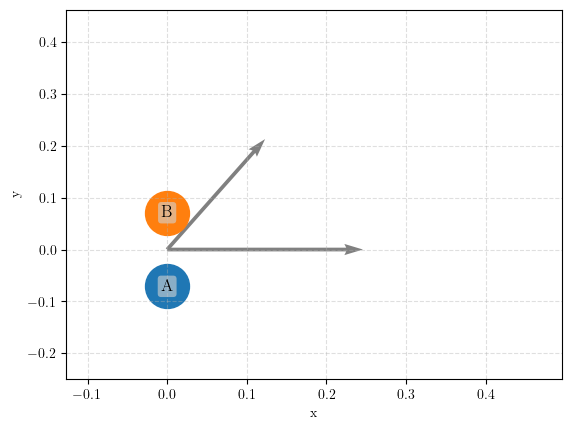

In [19]:
lat=pb_lattice_Haldane()
lat.plot()

In [20]:
model=jpb.Model(lat,'k',16,16)
solver=jpb.Solver(model)


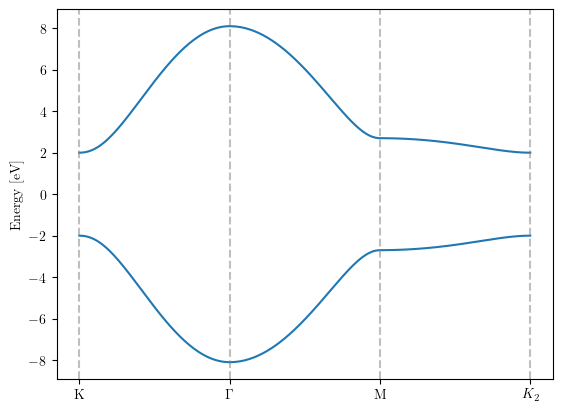

In [21]:
Gamma = [0, 0]
K1 = [-4*np.pi / (3*np.sqrt(3)*a_cc), 0]
M = [0, 2*np.pi / (3*a_cc)]
K2 = [2*np.pi / (3*np.sqrt(3)*a_cc), 2*np.pi / (3*a_cc)]

k_points=[K1,Gamma,M,K2]

ene_mat=solver.calc_bands(k_points,True,[r'K',r'$\Gamma$',r'M',r'$K_2$'])



# With Kane Mele

In [22]:
def pb_lattice_kane_mele(t=-2.7,m=0,lambda_I=- 1/(3*np.sqrt(3)) ,Bz=10):
    
    a = 0.24595   # [nm] unit cell length
    a_cc = 0.142  # [nm] carbon-carbon distance
    
    sz=np.array([[1,0],[0,-1]])

    lat = jpb.Lattice(
        a1=[a, 0],
        a2=[a/2, a/2 * np.sqrt(3)]
    )

    lat.add_sublattices(
        # name and position
        ('A', [0, -a_cc/2],-m*np.array([[1,0],[0,1]])+np.array([[Bz,0],[0,-Bz]])),
        ('B', [0,  a_cc/2],m*np.array([[1,0],[0,1]])+np.array([[Bz,0],[0,-Bz]]))
    )

    lat.add_hoppings(
        # inside the main cell
        ([0,  0], 'A', 'B', t*np.array([[1,0],[0,1]])),
        # between neighboring cells
        ([1, -1], 'A', 'B', t*np.array([[1,0],[0,1]])),
        ([0, -1], 'A', 'B', t*np.array([[1,0],[0,1]])),
        ([1, 0], 'A', 'A', lambda_I * 1j*sz),
        ([0, -1], 'A', 'A', lambda_I * 1j*sz),
        ([-1, 1], 'A', 'A', lambda_I * 1j*sz),

        ([1, 0], 'B', 'B', lambda_I * -1j*sz),
        ([0, -1], 'B', 'B', lambda_I * -1j*sz),
        ([-1, 1], 'B', 'B', lambda_I * -1j*sz)
    )

    return lat

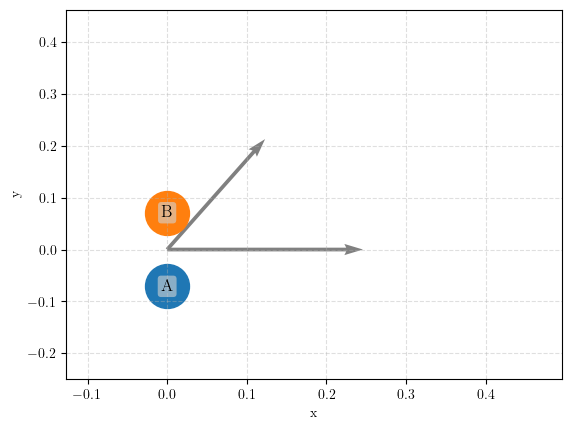

In [23]:
lat=pb_lattice_kane_mele()
lat.plot()

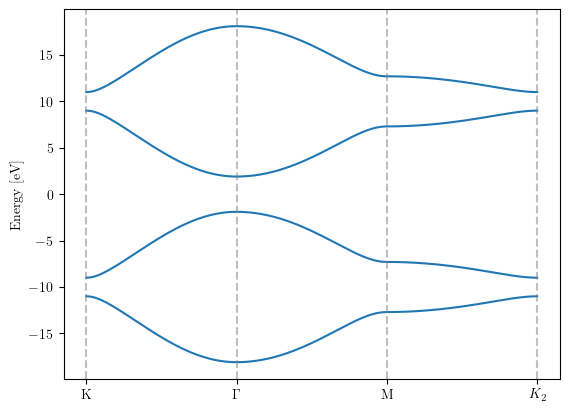

In [24]:
model=jpb.Model(lat,'k',16,16)
solver=jpb.Solver(model)
Gamma = [0, 0]
K1 = [-4*np.pi / (3*np.sqrt(3)*a_cc), 0]
M = [0, 2*np.pi / (3*a_cc)]
K2 = [2*np.pi / (3*np.sqrt(3)*a_cc), 2*np.pi / (3*a_cc)]

k_points=[K1,Gamma,M,K2]

ene_mat=solver.calc_bands(k_points,True,[r'K',r'$\Gamma$',r'M',r'$K_2$'])



# With multiorbital model

In [25]:
def Slater_Koaster_s_px_py_pz(e,Vsss,Vsps,Vpps,Vppp):

    ### Vector normalization
    e_norm=e/np.linalg.norm(e)

    ### Building the matrix
    t_mat=np.zeros((4,4),dtype=complex)
    
    ### s-s
    t_mat[0,0]=Vsss
    ### s-p
    # s-px hopping
    t_mat[0,1]=e_norm[0]*Vsps
    t_mat[1,0]=-e_norm[0]*Vsps
    # s-py hopping
    t_mat[0,2]=e_norm[1]*Vsps
    t_mat[2,0]=-e_norm[1]*Vsps
    # s-pz hopping
    t_mat[0,3]=e_norm[2]*Vsps
    t_mat[3,0]=-e_norm[2]*Vsps
            
    ### p-p


    # px-px hopping
    t_mat[1,1]=(e_norm[0]**2*Vpps+(1-e_norm[0]**2)*Vppp)
    # px-py hopping
    t_mat[1,2]=e_norm[0]*e_norm[1]*(Vpps-Vppp)
    # px-pz hopping
    t_mat[1,3]=e_norm[0]*e_norm[2]*(Vpps-Vppp)

    # py-py hopping
    t_mat[2,2]=(e_norm[1]**2*Vpps+(1-e_norm[1]**2)*Vppp)
    # py-px hopping
    t_mat[2,1]=e_norm[0]*e_norm[1]*(Vpps-Vppp)
    # py-pz hopping
    t_mat[2,3]=e_norm[1]*e_norm[2]*(Vpps-Vppp)
    
    # pz-pz hopping
    t_mat[3,3]=(e_norm[2]**2*Vpps+(1-e_norm[2]**2)*Vppp)
    # pz-px hopping
    t_mat[3,1]=e_norm[0]*e_norm[2]*(Vpps-Vppp)
    # pz-py hopping
    t_mat[3,2]=e_norm[1]*e_norm[2]*(Vpps-Vppp)


    return t_mat


def pb_lattice_square_SK_SOC(Es=3.2,Ep=-0.5,Vsss=0.5,Vsps=0.5,Vpps=0.5,Vppp=0.2,lambda_SOC=0.1):
    """
    Default parameters are extracted from : https://doi.org/10.1103/PhysRevLett.121.086602

    """

    
    d = 2  # [A] unit cell length
    pos_A=np.array([0, 0,0])
    a1=np.array([d, 0,0])
    a2=np.array([0, d,0])
    onsites=np.diag([Es,Ep,Ep,Ep])
    # SOC part
    Lx=np.array([[0,0,0,0],[0,0,0,0],[0,0,0,-1j],[0,0,1j,0]])
    Ly=np.array([[0,0,0,0],[0,0,0,1j],[0,0,0,0],[0,-1j,0,0]])
    Lz=np.array([[0,0,0,0],[0,0,-1j,0],[0,1j,0,0],[0,0,0,0]])

    Sx=0.5*np.array([[0,1],[1,0]])
    Sy=0.5*np.array([[0,-1j],[1j,0]])
    Sz=0.5*np.array([[1,0],[0,-1]])
    L_S=2*lambda_SOC*(np.kron(Lx,Sx)+np.kron(Ly,Sy)+np.kron(Lz,Sz))

    

    # print(Slater_Koaster_s_px_py_pz((1*a1+0*a2)+pos_A-pos_A,Vsss,Vsps,Vpps,Vppp))
    # print(Slater_Koaster_s_px_py_pz((0*a1+1*a2)+pos_A-pos_A,Vsss,Vsps,Vpps,Vppp))
    
    # create a simple 2D lattice with vectors a1 and a2
    lattice = jpb.Lattice(a1, a2)
    lattice.add_sublattices(
        ('A', pos_A ,np.kron(onsites,np.eye(2))+L_S),  # add an atom called 'A' at position [0, 0]
    )
    lattice.add_hoppings(
        # (relative_index, from_sublattice, to_sublattice, energy)
        ## Same lattice
        ([1, 0], 'A', 'A', np.kron(Slater_Koaster_s_px_py_pz((1*a1+0*a2)+pos_A-pos_A,Vsss,Vsps,Vpps,Vppp),np.eye(2))),
        ([0, 1], 'A', 'A', np.kron(Slater_Koaster_s_px_py_pz((0*a1+1*a2)+pos_A-pos_A,Vsss,Vsps,Vpps,Vppp),np.eye(2))), 
 )
    

    return lattice


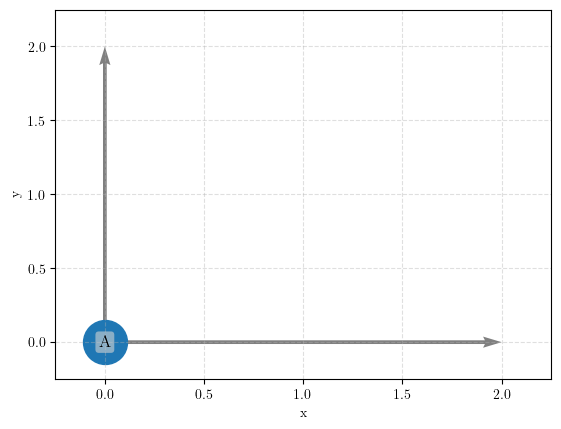

In [26]:
lat=pb_lattice_square_SK_SOC(Es=3.2,Ep=-0.5,Vsss=-0.5,Vsps=0.5,Vpps=0.5,Vppp=-0.2,lambda_SOC=0.05)
lat.plot()

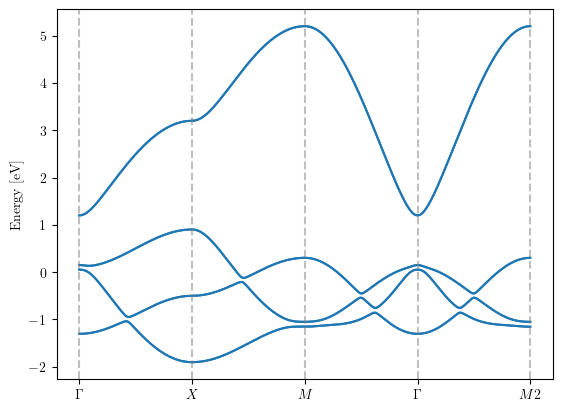

In [27]:

model=jpb.Model(lat,'k',16,16)
solver=jpb.Solver(model)
Gamma=[0,0,0]
X=[np.pi/2,0,0]
M=[np.pi/2,np.pi/2,0]
M2=[-np.pi/2,np.pi/2,0]
Y=[0,np.pi/2,0]

k_points_labels=[r'$\Gamma$',r'$X$',r'$M$',r'$\Gamma$',r'$M2$']
k_points=[Gamma,X,M,Gamma,M2]

ene_mat=solver.calc_bands(k_points,True,k_points_labels)

